# SWOOSH and AirCore N2O Comparison

SWOOSH comined ACE and MLS N2O data wre compared against NOAA AirCore N2O data (from Boulder). 

To do this, AirCore EqLat data is generated from ERA5 and MERRA-2. 

In [385]:
import sys
import os
import gc
import re
import io
import time
import requests
from datetime import datetime
import pathlib
from pathlib import Path
from glob import glob
from datetime import timedelta

# Data Analysis & Science
import numpy as np
import pandas as pd
import xarray as xr
import xesmf as xe
from bs4 import BeautifulSoup
import h5py 
from scipy import stats
from scipy.interpolate import RegularGridInterpolator

# Visualization
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
%matplotlib inline



In [386]:
era5_eqlat_dir =  "/Volumes/HOME/Data/era5_AirCore"
merra2_eqlat_dir =  "/Volumes/HOME/Data/merra2_AirCore"

data_dir = os.path.join(
    pathlib.Path.home(),
    'Documents',
    'GitHub',
    'eqlat_HPC',
    'data'
)

In [387]:
aircore_dir = os.path.join(data_dir, 'aircore/v20260615/level2')

n2o_aircores = []

for root, dirs, files in os.walk(aircore_dir):
    for file in files:
        if "N2O" in file:
            print(os.path.join(root, file))
            n2o_aircores.append(os.path.join(root, file))

/Users/jesswein/Documents/GitHub/eqlat_HPC/data/aircore/v20260615/level2/Flight_20240731/launch1/AirCoreGML017_202407311533_N2Ov20260612.txt
/Users/jesswein/Documents/GitHub/eqlat_HPC/data/aircore/v20260615/level2/Flight_20250930/launch1/AirCoreGML017_202509301501_N2Ov20260612.txt
/Users/jesswein/Documents/GitHub/eqlat_HPC/data/aircore/v20260615/level2/Flight_20251022/launch1/AirCoreGML011_202510221500_N2Ov20260612.txt
/Users/jesswein/Documents/GitHub/eqlat_HPC/data/aircore/v20260615/level2/Flight_20251022/launch2/AirCoreGML009_202510221500_N2Ov20260612.txt
/Users/jesswein/Documents/GitHub/eqlat_HPC/data/aircore/v20260615/level2/Flight_20230816/launch1/AirCoreGML008_202308161559_N2Ov20260612.txt
/Users/jesswein/Documents/GitHub/eqlat_HPC/data/aircore/v20260615/level2/Flight_20250618/launch1/AirCoreGML017_202506181532_N2Ov20260612.txt
/Users/jesswein/Documents/GitHub/eqlat_HPC/data/aircore/v20260615/level2/Flight_20250415/launch1/AirCoreGML020_202504151500_N2Ov20260612.txt
/Users/jesswe

In [388]:
def get_eqlat_aircore(aircore_path, method='piecewise'):
    """Interpolate ERA5 and MERRA2 equivalent latitude onto an AirCore profile.

    Reads the AirCore CSV, then interpolates the reanalysis 'eqlat' field
    at each AirCore level using its time, potential temperature, and
    location. If either reanalysis file or interpolation fails, that
    entry is left as None but the function still returns normally.

    Parameters
    ----------
    aircore_path : str
        Path to an AirCore level2 CSV file. The file name must contain a
        'YYYYMMDD' date token used to locate matching ERA5/MERRA2 files.
    method : str, default 'piecewise'
        Eqlat computation method, used to select the matching ERA5/MERRA2 file.

    Returns
    -------
    dict
        'aircore_data': the parsed AirCore DataFrame.
        'ERA5_eqlat': xr.DataArray of interpolated ERA5 eqlat, or None on failure.
        'MERRA2_eqlat': xr.DataArray of interpolated MERRA2 eqlat, or None on failure.
    """

    date = aircore_path.split('_')[-2][:-4]

    tmp_aircore = pd.read_csv(aircore_path)

    tmp_aircore['DateTime(yyyy-mm-dd HH:MM:SS)'] = pd.to_datetime(tmp_aircore['DateTime(yyyy-mm-dd HH:MM:SS)'], errors='coerce')

    target_time = xr.DataArray(tmp_aircore['DateTime(yyyy-mm-dd HH:MM:SS)'], dims='z')
    target_theta = xr.DataArray(tmp_aircore[' TH(K)'], dims='z')
    target_lat = xr.DataArray(tmp_aircore[' Lat(N)'], dims='z')
    target_lon = xr.DataArray(tmp_aircore[' Lon(E)'], dims='z')

    profile_eq_lat_era5 = None
    profile_eq_lat_merra2 = None

    try:
        era5_path = glob(f"{era5_eqlat_dir}/*{method}_{date}.nc")[0]
        era5_ds = xr.open_dataset(era5_path)

        profile_eq_lat_era5 = era5_ds["eqlat"].interp(
            valid_time=target_time,
            theta=target_theta,
            latitude=target_lat,
            longitude=target_lon % 360,
            method='linear'
        )

    except Exception as e:
        print(f"Error loading ERA5 eqlat: {e}")

    try:
        merra2_path = glob(f"{merra2_eqlat_dir}/*{method}_{date}.nc")[0]
        merra2_ds = xr.open_dataset(merra2_path)

        profile_eq_lat_merra2 = merra2_ds["eqlat"].interp(
            time=target_time,
            theta=target_theta,
            lat=target_lat,
            lon=target_lon,
            method='linear'
        )

    except Exception as e:
        print(f"Error loading MERRA2 eqlat: {e}")

    return {'aircore_data': tmp_aircore,
            'ERA5_eqlat': profile_eq_lat_era5,
            'MERRA2_eqlat': profile_eq_lat_merra2,
            }

In [389]:
def build_eqlat_dataframe(aircore_paths, method='piecewise'):
    """Combine AirCore profiles and their ERA5/MERRA2 eqlat interpolations into one DataFrame.

    Parameters
    ----------
    aircore_paths : list of str
        Paths to AirCore level2 CSV files.
    method : str, default 'piecewise'
        Eqlat computation method, used to select the matching ERA5/MERRA2 file.

    Returns
    -------
    pd.DataFrame
        All AirCore profiles concatenated, with 'aircore_file', 'ERA5_eqlat',
        and 'MERRA2_eqlat' columns added. Missing eqlat values are NaN.
    """
    all_profiles = []

    for aircore_path in aircore_paths:
        try:
            result = get_eqlat_aircore(aircore_path, method=method)
        except Exception as e:
            print(f"Skipping {aircore_path}: {e}")
            continue

        df = result['aircore_data'].copy()
        df['aircore_file'] = os.path.basename(aircore_path)

        era5 = result['ERA5_eqlat']
        df['ERA5_eqlat'] = era5.values if era5 is not None else np.nan

        merra2 = result['MERRA2_eqlat']
        df['MERRA2_eqlat'] = merra2.values if merra2 is not None else np.nan

        all_profiles.append(df)

    return pd.concat(all_profiles, ignore_index=True)


eqlat_df = build_eqlat_dataframe(n2o_aircores)
eqlat_df

,DateTime(yyyy-mm-dd HH:MM:SS),SecondsFromMidnight(s),Pressure(mb),Lat(N),Lon(E),Alt(m),CO2(ppm),co2_err(ppm),CH4(ppb),ch4_err,...,alt_err_co2+(m),alt_err_ch4-(m),alt_err_ch4+(m),alt_err_co5310-(m),alt_err_co5310+(m),alt_err_n2o-(m),alt_err_n2o+(m),aircore_file,ERA5_eqlat,MERRA2_eqlat
0,2024-07-31 17:03:51,61431.157772,18.407718,39.675403,-104.115223,28769.139077,NaN,0.25,NaN,13.46,...,NaN,2206.801548,NaN,2132.959540,NaN,1968.313263,NaN,AirCoreGML017_202407311533_N2Ov20260612.txt,37.814673,39.777549
1,2024-07-31 17:05:59,61559.614719,19.632294,39.678451,-104.148363,28265.102617,410.897514,0.24,1230.772835,12.78,...,NaN,2131.871673,NaN,2031.301675,NaN,1872.891308,NaN,AirCoreGML017_202407311533_N2Ov20260612.txt,35.789775,40.131956
2,2024-07-31 17:07:43,61663.040471,20.861214,39.681890,-104.175975,27791.301668,411.005876,0.22,1243.634316,11.80,...,NaN,1932.435288,NaN,1885.171307,NaN,1720.238577,NaN,AirCoreGML017_202407311533_N2Ov20260612.txt,34.156307,40.442226
3,2024-07-31 17:08:59,61739.401976,22.092059,39.682753,-104.193743,27356.007736,411.150420,0.21,1249.591705,11.18,...,NaN,1865.029901,NaN,1756.978617,NaN,1630.097520,NaN,AirCoreGML017_202407311533_N2Ov20260612.txt,34.261591,40.462143
4,2024-07-31 17:10:10,61810.032462,23.320974,39.685102,-104.214097,26944.676028,411.189522,0.20,1252.604136,10.76,...,1857.373435,1764.102191,NaN,1687.688576,NaN,1528.588118,1857.373435,AirCoreGML017_202407311533_N2Ov20260612.txt,35.640851,40.801593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31313,2024-05-14 16:54:31,60871.314490,828.340959,40.230310,-103.572871,1639.601706,434.915938,0.08,2085.769855,0.46,...,91.042892,68.148532,107.287968,91.299824,117.110346,56.427479,82.588885,AirCoreGML007_202405141500_N2Ov20260612.txt,NaN,NaN
31314,2024-05-14 16:54:36,60876.900489,831.002288,40.230201,-103.572739,1611.197518,434.914536,0.08,2094.038326,0.46,...,77.459593,79.506466,98.300428,104.329919,88.496486,83.596183,100.486702,AirCoreGML007_202405141500_N2Ov20260612.txt,NaN,NaN
31315,2024-05-14 16:54:42,60882.353959,833.546362,40.230159,-103.572509,1583.113357,435.076488,0.08,2101.185773,0.46,...,87.011059,93.689947,96.094962,68.342323,127.379550,77.499589,98.977975,AirCoreGML007_202405141500_N2Ov20260612.txt,NaN,NaN
31316,2024-05-14 16:54:48,60888.090430,836.237029,40.230037,-103.572144,1557.111626,435.039805,0.08,2109.638867,0.46,...,90.395372,94.268234,123.567526,65.925177,99.544219,45.370670,119.236931,AirCoreGML007_202405141500_N2Ov20260612.txt,NaN,NaN


In [390]:
def decimal_year_to_datetime(decimal_year):
    decimal_year = np.asarray(decimal_year, dtype=float)
    year = np.floor(decimal_year).astype(int)
    remainder = decimal_year - year

    start = pd.to_datetime(year.astype(str), format='%Y')
    end = pd.to_datetime((year + 1).astype(str), format='%Y')

    return start + remainder * (end - start)


In [391]:
swoosh_n2o = xr.open_dataset('/Users/jesswein/Documents/GitHub/eqlat_HPC/data/satellite/ACE_MLS_combined_N2O_v2.nc')

In [392]:
swoosh_n2o

<xarray.Dataset> Size: 6MB
Dimensions:   (nt: 505, nz: 31, ny: 18)
Dimensions without coordinates: nt, nz, ny
Data variables:
    N2O_comb  (nt, nz, ny) float32 1MB ...
    N2O_MLS   (nt, nz, ny) float32 1MB ...
    N2O_ACE   (nt, nz, ny) float32 1MB ...
    Lat       (ny) float32 72B ...
    Time      (nt) float32 2kB ...
    O3        (nt, nz, ny) float32 1MB ...
    Theta     (nt, nz, ny) float32 1MB ...
    Pressure  (nz) float32 124B ...
Attributes:
    Title:    ACE/MLS N2O Combined Product v2.  Uses MLS v6 N2O.

In [393]:
swoosh_n2o = swoosh_n2o.assign_coords(
    Time=('nt', decimal_year_to_datetime(swoosh_n2o['Time'].values)),
    Lat=('ny', swoosh_n2o['Lat'].values),
).swap_dims({'nt': 'Time', 'ny': 'Lat'})

In [394]:
swoosh_n2o

<xarray.Dataset> Size: 6MB
Dimensions:   (Time: 505, nz: 31, Lat: 18)
Coordinates:
  * Time      (Time) datetime64[us] 4kB 1984-01-16T05:38:33.281250 ... 2026-0...
  * Lat       (Lat) float32 72B -85.0 -75.0 -65.0 -55.0 ... 55.0 65.0 75.0 85.0
Dimensions without coordinates: nz
Data variables:
    N2O_comb  (Time, nz, Lat) float32 1MB ...
    N2O_MLS   (Time, nz, Lat) float32 1MB ...
    N2O_ACE   (Time, nz, Lat) float32 1MB ...
    O3        (Time, nz, Lat) float32 1MB ...
    Theta     (Time, nz, Lat) float32 1MB ...
    Pressure  (nz) float32 124B ...
Attributes:
    Title:    ACE/MLS N2O Combined Product v2.  Uses MLS v6 N2O.

In [395]:
def bin_theta_profile(n2o_profile, theta_profile, theta_bins):
    """Average one (pressure-level) N2O profile into fixed potential-temperature bins."""
    # assign each pressure level to a theta bin based on its actual (time/lat-dependent) theta value
    bin_idx = np.digitize(theta_profile, theta_bins) - 1
    binned = np.full(len(theta_bins) - 1, np.nan)
    for i in range(len(theta_bins) - 1):
        mask = bin_idx == i
        if mask.any():
            # average all pressure levels that fall into this theta bin
            binned[i] = np.nanmean(n2o_profile[mask])
    return binned


theta_bins = np.arange(300, 1400, 50)          # K, bin edges
theta_centers = 0.5 * (theta_bins[:-1] + theta_bins[1:])  # bin midpoints, used as the new theta coordinate

# apply the binning function to every (Time, Lat) profile at once, replacing the
# pressure-level dim 'nz' with the new fixed 'theta' dim
n2o_theta = xr.apply_ufunc(
    bin_theta_profile,
    swoosh_n2o['N2O_comb'],
    swoosh_n2o['Theta'],           # per-point theta values, same shape as N2O_comb
    input_core_dims=[['nz'], ['nz']],
    output_core_dims=[['theta']],
    exclude_dims={'nz'},           # output size along this axis differs from the input
    vectorize=True,                # loop bin_theta_profile over all other (Time, Lat) combinations
    kwargs={'theta_bins': theta_bins},
)
n2o_theta = n2o_theta.assign_coords(theta=theta_centers)  # attach the fixed theta grid as a coordinate
n2o_theta.name = 'N2O_comb'
n2o_theta

/var/folders/_x/vj_l8lbd6739nqm7v3yptrmw0010ht/T/ipykernel_51589/1644812724.py:10: RuntimeWarning: Mean of empty slice
  binned[i] = np.nanmean(n2o_profile[mask])


<xarray.DataArray 'N2O_comb' (Time: 505, Lat: 18, theta: 21)> Size: 2MB
array([[[         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        ...,
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan]],

       [[         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
...
        [336.86853027, 304.42044067, 251.62585449, ...,          nan,
           5.50930834,   4.77953339],
        [336.09146118, 300.52645874, 239.65844727, ...,   3.82569671,
                  nan,   2.89891148],
        [336.30566406, 305.69342041, 229.35096741, ...,   2.12606311,
                  nan,   1.39568043]],

       [[335.98358154, 308.91671753, 241.59783936, ...,  19.24447441,
          13.25764847,          nan],
        [336.25769043, 313.71432495, 256.33322144, ...,          nan,
          15.44663334,          nan],
        [337.67553711, 319.68225098, 272.30206299, ...,          nan,
          15.18029594,          nan],
        ...,
        [335.42565918, 299.13571167, 249.26147461, ...,          nan,
           9.11692429,   8.74757481],
        [336.05130005, 294.17501831, 222.78538513, ...,   6.67979956,
                  nan,   6.08002472],
        [335.45178223, 292.18148804, 213.16960144, ...,          nan,
           3.22293782,          nan]]], shape=(505, 18, 21))
Coordinates:
  * Time     (Time) datetime64[us] 4kB 1984-01-16T05:38:33.281250 ... 2026-01...
  * Lat      (Lat) float32 72B -85.0 -75.0 -65.0 -55.0 ... 55.0 65.0 75.0 85.0
  * theta    (theta) float64 168B 325.0 375.0 425.0 ... 1.275e+03 1.325e+03
Attributes:
    units:        ppbv
    description:  Combined N2O

In [396]:
# log-spaced pressure bin edges, ordered from large (surface) to small (top) pressure:
# since consecutive bin edges keep a constant ratio, the absolute bin width
# shrinks as pressure decreases, i.e. bin size decreases logarithmically with increasing height
pressure_bins = np.logspace(
    np.log10(swoosh_n2o['Pressure'].max().item()),
    np.log10(swoosh_n2o['Pressure'].min().item()),
    30,
)
# geometric mean (not arithmetic mean) is the natural bin center on a log-spaced grid
pressure_centers = np.sqrt(pressure_bins[:-1] * pressure_bins[1:])

# Pressure(nz) is fixed (same for every Time/Lat), unlike Theta, but apply_ufunc
# broadcasts it against N2O_comb automatically, so we can reuse bin_theta_profile as-is
n2o_pressure = xr.apply_ufunc(
    bin_theta_profile,
    swoosh_n2o['N2O_comb'],
    swoosh_n2o['Pressure'],
    input_core_dims=[['nz'], ['nz']],
    output_core_dims=[['pressure']],
    exclude_dims={'nz'},
    vectorize=True,
    kwargs={'theta_bins': pressure_bins},
)
n2o_pressure = n2o_pressure.assign_coords(pressure=pressure_centers)
n2o_pressure.name = 'N2O_comb'
n2o_pressure

/var/folders/_x/vj_l8lbd6739nqm7v3yptrmw0010ht/T/ipykernel_51589/1644812724.py:10: RuntimeWarning: Mean of empty slice
  binned[i] = np.nanmean(n2o_profile[mask])


<xarray.DataArray 'N2O_comb' (Time: 505, Lat: 18, pressure: 29)> Size: 2MB
array([[[            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        ...,
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
...
          3.89668322e+00,  3.27608705e+00,  2.47324944e+00],
        [ 3.38635193e+02,  3.31003967e+02,  3.18214111e+02, ...,
          2.56437325e+00,  2.50381637e+00,  2.32655239e+00],
        [ 3.38636078e+02,  3.31644867e+02,  3.21014984e+02, ...,
          1.28084564e+00,  1.44706893e+00,  2.02884150e+00]],

       [[ 3.35983582e+02,  3.20340881e+02,  3.11063782e+02, ...,
          2.88548708e+00,  2.92213202e+00,  2.43337202e+00],
        [ 3.36257690e+02,  3.23183807e+02,  3.15752563e+02, ...,
          2.49571514e+00,  1.40929103e+00,  9.90109324e-01],
        [ 3.37675537e+02,  3.25649261e+02,  3.21405701e+02, ...,
          8.84080052e-01, -1.64793000e-01, -1.51294425e-01],
        ...,
        [ 3.38556885e+02,  3.29163239e+02,  3.15204315e+02, ...,
          7.30906487e+00,  6.12986660e+00,  3.93788242e+00],
        [ 3.39102173e+02,  3.29949524e+02,  3.13720673e+02, ...,
          5.29933643e+00,  4.80141354e+00,  3.45050454e+00],
        [ 3.38725525e+02,  3.28904327e+02,  3.12838440e+02, ...,
          2.54558206e+00,  2.14490819e+00,  2.04827595e+00]]],
      shape=(505, 18, 29))
Coordinates:
  * Time      (Time) datetime64[us] 4kB 1984-01-16T05:38:33.281250 ... 2026-0...
  * Lat       (Lat) float32 72B -85.0 -75.0 -65.0 -55.0 ... 55.0 65.0 75.0 85.0
  * pressure  (pressure) float64 232B 286.3 234.8 192.5 ... 1.643 1.347 1.104
Attributes:
    units:        ppbv
    description:  Combined N2O

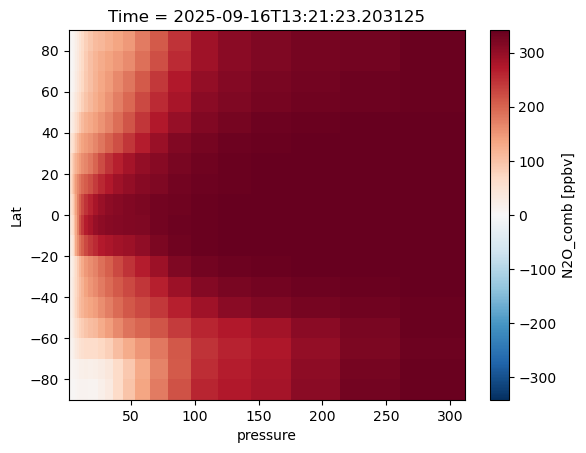

In [397]:
n2o_pressure[500, :, :].plot()

In [398]:
n2o_pressure_recent = n2o_pressure.sel(Time=slice('2005', '2025'))

n2o_pressure_seasonal = n2o_pressure_recent.groupby('Time.season').mean('Time', skipna=True)
n2o_pressure_seasonal

<xarray.DataArray 'N2O_comb' (season: 4, Lat: 18, pressure: 29)> Size: 17kB
array([[[3.23861647e+02, 3.07714292e+02, 2.98672755e+02, ...,
         2.40522124e+00, 1.51972057e+00, 1.02886879e+00],
        [3.23967026e+02, 3.09820992e+02, 3.01988083e+02, ...,
         2.76048036e+00, 1.81251870e+00, 1.28787520e+00],
        [3.25005757e+02, 3.12454807e+02, 3.09003559e+02, ...,
         2.00601968e+00, 1.28413791e+00, 8.00059335e-01],
        ...,
        [3.27561635e+02, 3.18519475e+02, 3.05623126e+02, ...,
         5.21784623e+00, 4.44148387e+00, 3.34814644e+00],
        [3.27979628e+02, 3.19634744e+02, 3.06038353e+02, ...,
         4.15660524e+00, 3.62652637e+00, 2.74178192e+00],
        [3.27737153e+02, 3.19109001e+02, 3.06302293e+02, ...,
         3.43206370e+00, 3.13927821e+00, 2.48398906e+00]],

       [[3.28511238e+02, 3.24509314e+02, 3.13587992e+02, ...,
         1.13742398e+00, 1.01373023e+00, 8.80193733e-01],
        [3.28110479e+02, 3.23750608e+02, 3.11847630e+02, ...,
         1.67117560e+00, 1.46607896e+00, 1.28691888e+00],
        [3.27335901e+02, 3.20425919e+02, 3.09111977e+02, ...,
         2.46799882e+00, 2.04446196e+00, 1.59308928e+00],
...
         5.84439476e+00, 4.24801763e+00, 2.79088945e+00],
        [3.23862082e+02, 3.05739197e+02, 2.93099161e+02, ...,
         5.92417634e+00, 4.32167555e+00, 2.81714184e+00],
        [3.22922856e+02, 3.03471776e+02, 2.91060772e+02, ...,
         6.16208861e+00, 4.55963942e+00, 3.03766594e+00]],

       [[3.24762229e+02, 3.07542627e+02, 2.81162994e+02, ...,
         2.98778960e+00, 2.25098946e+00, 1.70659311e+00],
        [3.22899229e+02, 3.05206067e+02, 2.78970232e+02, ...,
         4.01423766e+00, 3.03095990e+00, 2.30106448e+00],
        [3.22797759e+02, 2.99265375e+02, 2.79170274e+02, ...,
         5.06238221e+00, 3.77627515e+00, 2.74649919e+00],
        ...,
        [3.28112805e+02, 3.23337958e+02, 3.17809564e+02, ...,
         1.50747252e+00, 1.22561670e+00, 1.03411854e+00],
        [3.27685803e+02, 3.22382290e+02, 3.16718201e+02, ...,
         5.52061592e-01, 5.58272613e-01, 5.52693655e-01],
        [3.27505930e+02, 3.21853257e+02, 3.16771974e+02, ...,
         1.19659328e-01, 2.99694455e-01, 4.03028391e-01]]],
      shape=(4, 18, 29))
Coordinates:
  * season    (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * Lat       (Lat) float32 72B -85.0 -75.0 -65.0 -55.0 ... 55.0 65.0 75.0 85.0
  * pressure  (pressure) float64 232B 286.3 234.8 192.5 ... 1.643 1.347 1.104
Attributes:
    units:        ppbv
    description:  Combined N2O

In [399]:
n2o_theta_recent = n2o_theta.sel(Time=slice('2015', '2025'))

n2o_theta_seasonal = n2o_theta_recent.groupby('Time.season').mean('Time', skipna=True)
n2o_theta_seasonal

<xarray.DataArray 'N2O_comb' (season: 4, Lat: 18, theta: 21)> Size: 12kB
array([[[325.32437504, 298.7558677 , 235.31330039, ...,  17.07512052,
          14.9215765 ,  10.84374079],
        [325.67787032, 300.18920251, 242.87817891, ...,  16.15369357,
          16.87943543,   6.38270142],
        [327.38541389, 310.10912161, 263.71546566, ...,   7.99346597,
          15.27246909,   4.82568554],
        ...,
        [328.25691454, 291.07581769, 235.29672195, ...,   9.20040035,
           6.74730642,   7.99523841],
        [326.84610725, 283.88245276, 218.05743408, ...,   7.43417186,
           4.84038838,   5.87189153],
        [325.5453186 , 282.82766215, 208.62426943, ...,   5.57034607,
           4.52429755,   4.48486078]],

       [[317.73573627, 245.81910844, 168.14106149, ...,   1.28684993,
           1.52318533,   1.12332849],
        [321.7700334 , 257.54128289, 173.08548251, ...,   1.99037878,
           1.93525166,   1.46621125],
        [325.30017367, 277.74348588, 208.89262714, ...,   3.86628255,
           3.62834559,   2.8705501 ],
...
        [324.55980983, 293.17816809, 252.90604886, ...,  15.13841302,
          15.30609781,  12.79201533],
        [323.18438351, 285.39408273, 238.02239389, ...,  15.74814275,
          15.32340357,  12.40389092],
        [321.72554895, 282.41547926, 231.96685537, ...,  16.07697365,
          15.25712487,  12.72133761]],

       [[300.16672215, 234.49683265, 158.41786702, ...,  10.11051594,
          11.69220474,   7.81486498],
        [306.40061072, 235.51052117, 161.71184702, ...,  16.27396863,
          11.63814592,  11.19122702],
        [313.38789691, 253.6979532 , 201.75060665, ...,  21.63690222,
          12.15380847,  15.11198189],
        ...,
        [331.44728782, 316.1303378 , 279.85637827, ...,   3.85456559,
           3.5420942 ,   2.38996239],
        [330.71168102, 314.60579797, 274.63169445, ...,   1.3334482 ,
           1.90517329,   0.55444772],
        [330.66715125, 316.01925474, 273.47524932, ...,   1.43960639,
           0.8312199 ,   0.53909857]]], shape=(4, 18, 21))
Coordinates:
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * Lat      (Lat) float32 72B -85.0 -75.0 -65.0 -55.0 ... 55.0 65.0 75.0 85.0
  * theta    (theta) float64 168B 325.0 375.0 425.0 ... 1.275e+03 1.325e+03
Attributes:
    units:        ppbv
    description:  Combined N2O

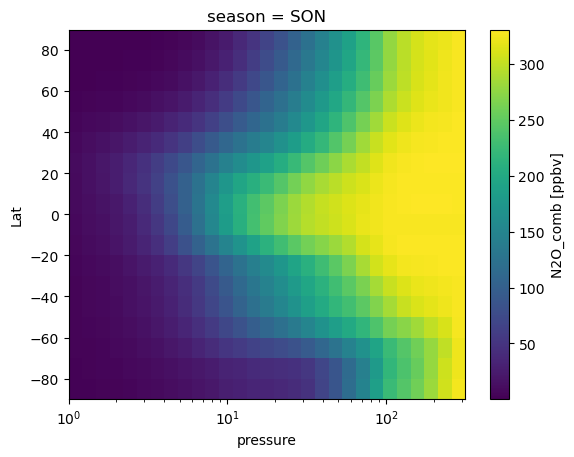

In [400]:
n2o_pressure_seasonal[3, :, :].plot(x='pressure', y='Lat', xscale='log')

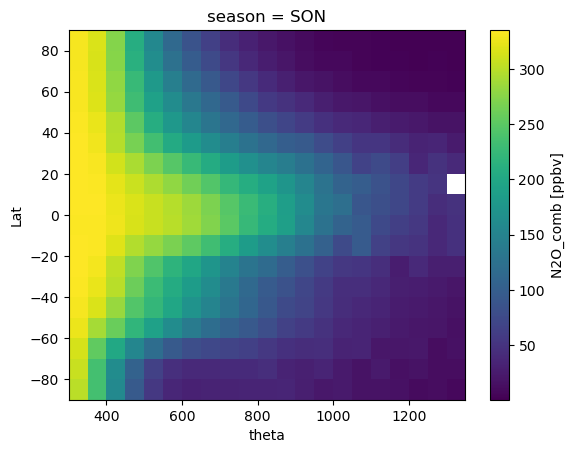

In [401]:
n2o_theta_seasonal[3, :, :].plot()

In [402]:
def bin_n2o_eqlat(df, eqlat_col, n2o_col=' N2O(ppb)', bin_col=' TH(K)',
                         eqlat_bins=np.arange(-90, 91, 10), bins=np.arange(300, 2000, 50),
                         log_bins=False, min_count=3):
    """Average AirCore N2O onto an equivalent-latitude x vertical-coordinate grid.

    Set log_bins=True for a log-spaced vertical coordinate (e.g. pressure,
    ordered increasing since pd.cut requires monotonically increasing bins),
    matching the SWOOSH pressure binning: bin centers then use the geometric
    mean instead of the arithmetic mean, and the output dim is named 'pressure'.

    Returns a Dataset with 'mean', 'std', and 'count' variables per bin (index
    with ds['mean'] etc. - 'mean' as an attribute is shadowed by Dataset.mean()).
    'count' is the raw observation count in every bin; 'mean' and 'std' are
    left as NaN for bins with fewer than min_count observations.
    """
    eqlat_centers = 0.5 * (eqlat_bins[:-1] + eqlat_bins[1:])
    theta_centers = (np.sqrt(bins[:-1] * bins[1:]) if log_bins
                      else 0.5 * (bins[:-1] + bins[1:]))

    valid = df[[eqlat_col, bin_col, n2o_col]].dropna()

    eqlat_idx = pd.cut(valid[eqlat_col], eqlat_bins, labels=False)
    theta_idx = pd.cut(valid[bin_col], bins, labels=False)

    shape = (len(eqlat_centers), len(theta_centers))
    mean_binned = np.full(shape, np.nan)
    std_binned = np.full(shape, np.nan)
    count_binned = np.zeros(shape, dtype=int)
    grouped = valid.groupby([eqlat_idx, theta_idx], observed=True)[n2o_col].agg(['mean', 'std', 'count'])

    for (i, j), row in grouped.iterrows():
        count_binned[int(i), int(j)] = row['count']
        if row['count'] >= min_count:
            mean_binned[int(i), int(j)] = row['mean']
            std_binned[int(i), int(j)] = row['std']

    vert_dim = 'pressure' if log_bins else 'theta'
    dims = ['eqlat', vert_dim]
    coords = {'eqlat': eqlat_centers, vert_dim: theta_centers}
    return xr.Dataset(
        {
            'mean': (dims, mean_binned),
            'std': (dims, std_binned),
            'count': (dims, count_binned),
        },
        coords=coords,
        attrs={'name': n2o_col.strip()},
    )


# log-spaced pressure bin edges for the AirCore data, same idea as the SWOOSH pressure
# binning, but increasing (min -> max) since pd.cut needs monotonically increasing bins.
# a few Pressure(mb) values are ~0 or slightly negative (floating-point noise near the
# top of a profile), which would make log10() NaN and break pd.cut, so filter those out first
positive_pressure = eqlat_df.loc[eqlat_df[' Pressure(mb)'] > 0, ' Pressure(mb)']
pressure_bins_aircore = np.logspace(
    np.log10(positive_pressure.min()),
    np.log10(positive_pressure.max()),
    30,
)

n2o_era5_eqlat_pressure = bin_n2o_eqlat(eqlat_df, 'ERA5_eqlat', bin_col=' Pressure(mb)',
                                               bins=pressure_bins_aircore, log_bins=True)
n2o_merra2_eqlat_pressure = bin_n2o_eqlat(eqlat_df, 'MERRA2_eqlat', bin_col=' Pressure(mb)',
                                                 bins=pressure_bins_aircore, log_bins=True)

#n2o_era5_eqlat_theta = bin_n2o_eqlat(eqlat_df, 'ERA5_eqlat')
#n2o_merra2_eqlat_theta = bin_n2o_eqlat(eqlat_df, 'MERRA2_eqlat')

In [403]:
SEASON_MAP = {12: 'DJF', 1: 'DJF', 2: 'DJF',
              3: 'MAM', 4: 'MAM', 5: 'MAM',
              6: 'JJA', 7: 'JJA', 8: 'JJA',
              9: 'SON', 10: 'SON', 11: 'SON'}


def bin_n2o_eqlat_theta_seasonal(df, eqlat_col, n2o_col=' N2O(ppb)', bin_col=' TH(K)',
                                  time_col='DateTime(yyyy-mm-dd HH:MM:SS)',
                                  eqlat_bins=np.arange(-90, 91, 10), bins=np.arange(300, 1400, 50),
                                  log_bins=False):
    """Same as bin_n2o_eqlat, but split into DJF/MAM/JJA/SON before binning.

    Set log_bins=True for a log-spaced vertical coordinate like pressure,
    same as bin_n2o_eqlat.
    """
    season = pd.to_datetime(df[time_col]).dt.month.map(SEASON_MAP)

    binned_per_season = {
        s: bin_n2o_eqlat(df[season == s], eqlat_col, n2o_col, bin_col, eqlat_bins, bins, log_bins)
        for s in ['DJF', 'MAM', 'JJA', 'SON']
    }
    return xr.concat(binned_per_season.values(), dim=pd.Index(binned_per_season.keys(), name='season'))


n2o_era5_eqlat_theta_seasonal = bin_n2o_eqlat_theta_seasonal(eqlat_df, 'ERA5_eqlat')
n2o_merra2_eqlat_theta_seasonal = bin_n2o_eqlat_theta_seasonal(eqlat_df, 'MERRA2_eqlat')

n2o_era5_eqlat_pressure_seasonal = bin_n2o_eqlat_theta_seasonal(eqlat_df, 'ERA5_eqlat', bin_col=' Pressure(mb)',
                                                                  bins=pressure_bins_aircore, log_bins=True)
n2o_merra2_eqlat_pressure_seasonal = bin_n2o_eqlat_theta_seasonal(eqlat_df, 'MERRA2_eqlat', bin_col=' Pressure(mb)',
                                                                    bins=pressure_bins_aircore, log_bins=True)

In [404]:
n2o_era5_eqlat_theta_seasonal

<xarray.Dataset> Size: 37kB
Dimensions:  (season: 4, eqlat: 18, theta: 21)
Coordinates:
  * season   (season) StringDType(na_object=nan) 64B 'DJF' 'MAM' 'JJA' 'SON'
  * eqlat    (eqlat) float64 144B -85.0 -75.0 -65.0 -55.0 ... 65.0 75.0 85.0
  * theta    (theta) float64 168B 325.0 375.0 425.0 ... 1.275e+03 1.325e+03
Data variables:
    mean     (season, eqlat, theta) float64 12kB nan nan nan nan ... nan nan nan
    std      (season, eqlat, theta) float64 12kB nan nan nan nan ... nan nan nan
    count    (season, eqlat, theta) int64 12kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
Attributes:
    name:     N2O(ppb)

In [405]:
def plot_swoosh_aircore_comparison(season, vertical='theta'):
    """Compare SWOOSH and AirCore (ERA5/MERRA2 EqLat) N2O, Northern Hemisphere only, one season.

    vertical: 'theta' or 'pressure' - which vertical binning of the data to use.
    """
    if vertical == 'theta':
        swoosh_data = n2o_theta_seasonal
        era5_data = n2o_era5_eqlat_theta_seasonal
        merra2_data = n2o_merra2_eqlat_theta_seasonal
        vert_dim = 'theta'
        ylabel = '$\Theta$ [K]'
    elif vertical == 'pressure':
        swoosh_data = n2o_pressure_seasonal
        era5_data = n2o_era5_eqlat_pressure_seasonal
        merra2_data = n2o_merra2_eqlat_pressure_seasonal
        vert_dim = 'pressure'
        ylabel = 'Pressure [hPa]'
    else:
        raise ValueError(f"vertical must be 'theta' or 'pressure', got {vertical!r}")

    swoosh_nh = swoosh_data.sel(season=season, Lat=slice(0, 90))
    era5_nh = era5_data.sel(season=season, eqlat=slice(0, 90))['mean']
    merra2_nh = merra2_data.sel(season=season, eqlat=slice(0, 90))['mean']

    vmax = max(swoosh_nh.max().item(), era5_nh.max().item(), merra2_nh.max().item())

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

    swoosh_nh.plot(ax=axes[0], x='Lat', y=vert_dim, vmin=0, vmax=vmax, add_colorbar=False)
    axes[0].set_title(f'SWOOSH ({season})')
    axes[0].set_xlabel('Latitude [°]')
    axes[0].set_ylabel(ylabel)

    era5_nh.plot(ax=axes[1], x='eqlat', y=vert_dim, vmin=0, vmax=vmax, add_colorbar=False)
    axes[1].set_title(f'AirCore, ERA5 EqLat ({season})')
    axes[1].set_xlabel('Equivalent Latitude [°]')
    axes[1].set_ylabel('')

    im = merra2_nh.plot(ax=axes[2], x='eqlat', y=vert_dim, vmin=0, vmax=vmax, add_colorbar=False)
    axes[2].set_title(f'AirCore, MERRA-2 EqLat ({season})')
    axes[2].set_xlabel('Equivalent Latitude [°]')
    axes[2].set_ylabel('')

    if vertical == 'theta':
        for ax in axes:
            ax.set_ylim(350, 1000)
    else:
        # pressure decreases with height, so flip the (shared) y-axis to read bottom-to-top
        axes[0].set_yscale('log')
        axes[0].invert_yaxis()
        for ax in axes:
            ax.set_ylim(400, 5)

    fig.colorbar(im, ax=axes, label='$N_2O$ [ppb]', shrink=0.8)
    return fig, axes


# fig, axes = plot_swoosh_aircore_comparison('DJF', vertical='theta')

<>:11: SyntaxWarning: invalid escape sequence '\T'
<>:11: SyntaxWarning: invalid escape sequence '\T'
/var/folders/_x/vj_l8lbd6739nqm7v3yptrmw0010ht/T/ipykernel_51589/861873360.py:11: SyntaxWarning: invalid escape sequence '\T'
  ylabel = '$\Theta$ [K]'


In [406]:
def plot_swoosh_aircore_diff(season, vertical='theta'):
    """Plot AirCore-minus-SWOOSH N2O differences (ERA5, MERRA2, ERA5 vs MERRA2), NH only, one season.

    vertical: 'theta' or 'pressure' - which vertical binning of the data to use.
    """
    if vertical == 'theta':
        swoosh_data = n2o_theta_seasonal
        era5_data = n2o_era5_eqlat_theta_seasonal
        merra2_data = n2o_merra2_eqlat_theta_seasonal
        vert_dim = 'theta'
        ylabel = '$\Theta$ [K]'
    elif vertical == 'pressure':
        swoosh_data = n2o_pressure_seasonal
        era5_data = n2o_era5_eqlat_pressure_seasonal
        merra2_data = n2o_merra2_eqlat_pressure_seasonal
        vert_dim = 'pressure'
        ylabel = 'Pressure [hPa]'
    else:
        raise ValueError(f"vertical must be 'theta' or 'pressure', got {vertical!r}")

    swoosh_nh = swoosh_data.sel(season=season, Lat=slice(0, 90))
    era5_nh = era5_data.sel(season=season, eqlat=slice(0, 90))['mean'].rename({'eqlat': 'Lat'})
    merra2_nh = merra2_data.sel(season=season, eqlat=slice(0, 90))['mean'].rename({'eqlat': 'Lat'})

    if vertical == 'pressure':
        # SWOOSH and AirCore were binned onto different pressure grids (different range,
        # opposite ordering), so their coordinate values don't line up for a direct
        # subtraction - interpolate the AirCore data onto SWOOSH's pressure grid first
        era5_nh = era5_nh.interp({vert_dim: swoosh_nh[vert_dim]})
        merra2_nh = merra2_nh.interp({vert_dim: swoosh_nh[vert_dim]})

    diff_era5_swoosh = era5_nh - swoosh_nh
    diff_merra2_swoosh = merra2_nh - swoosh_nh
    diff_era5_merra2 = era5_nh - merra2_nh

    vabs = max(abs(diff_era5_swoosh).max().item(),
               abs(diff_merra2_swoosh).max().item(),
               abs(diff_era5_merra2).max().item())

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

    diff_era5_swoosh.plot(ax=axes[0], x='Lat', y=vert_dim, cmap='RdBu_r', vmin=-vabs, vmax=vabs, add_colorbar=False)
    axes[0].set_title(f'AC (ERA5) − SWOOSH ({season})')
    axes[0].set_xlabel('Latitude / EqLat [°]')
    axes[0].set_ylabel(ylabel)

    diff_merra2_swoosh.plot(ax=axes[1], x='Lat', y=vert_dim, cmap='RdBu_r', vmin=-vabs, vmax=vabs, add_colorbar=False)
    axes[1].set_title(f'AC (MERRA-2) − SWOOSH ({season})')
    axes[1].set_xlabel('Latitude / EqLat [°]')
    axes[1].set_ylabel('')

    im = diff_era5_merra2.plot(ax=axes[2], x='Lat', y=vert_dim, cmap='RdBu_r', vmin=-vabs, vmax=vabs, add_colorbar=False)
    axes[2].set_title(f'AC (ERA5) − AC (MERRA-2) ({season})')
    axes[2].set_xlabel('Latitude / EqLat [°]')
    axes[2].set_ylabel('')

    if vertical == 'theta':
        for ax in axes:
            ax.set_ylim(350, 1000)
    else:
        # pressure decreases with height, so flip the (shared) y-axis to read bottom-to-top;
        # limited to SWOOSH's own pressure range, since that's what both sides were interpolated to
        axes[0].set_yscale('log')
        axes[0].invert_yaxis()
        for ax in axes:
            ax.set_ylim(400, 5)

    fig.colorbar(im, ax=axes, label='Δ$N_2O$ [ppb]', shrink=0.8)
    return fig, axes, (diff_era5_swoosh, diff_merra2_swoosh, diff_era5_merra2)


# fig, axes, (diff_era5_swoosh, diff_merra2_swoosh, diff_era5_merra2) = plot_swoosh_aircore_diff('DJF', vertical='theta')

<>:11: SyntaxWarning: invalid escape sequence '\T'
<>:11: SyntaxWarning: invalid escape sequence '\T'
/var/folders/_x/vj_l8lbd6739nqm7v3yptrmw0010ht/T/ipykernel_51589/2220767144.py:11: SyntaxWarning: invalid escape sequence '\T'
  ylabel = '$\Theta$ [K]'


In [422]:
def invert_swoosh_lat(swoosh_profile):
    """Invert a single-theta SWOOSH N2O(Lat) profile (NH only) to get Lat(N2O).

    Returns (n2o_sorted, lat_sorted) suitable for np.interp: NaNs are dropped
    and the profile is sorted by N2O value so np.interp always sees an
    increasing x-array. Mildly non-monotonic profiles are tolerated but not
    corrected for -- see plot_swoosh_aircore_delta_lat docstring.
    """
    valid = swoosh_profile.notnull()
    n2o_vals = swoosh_profile.where(valid, drop=True).values
    lat_vals = swoosh_profile['Lat'].where(valid, drop=True).values
    if len(n2o_vals) < 2:
        return None
    order = np.argsort(n2o_vals)
    return n2o_vals[order], lat_vals[order]


def compute_swoosh_matched_delta_lat(eqlat_data, swoosh_data, season):
    """For each (eqlat, theta) AirCore bin, find the SWOOSH latitude (same
    season/theta, NH only) whose N2O value matches the AirCore bin's N2O
    mean, and return eqlat - matched_lat.

    This re-expresses the AirCore/SWOOSH N2O mismatch as an
    equivalent-latitude offset instead of a ppb difference: it answers "at
    what real latitude would SWOOSH show this same N2O value?". SWOOSH
    N2O(Lat) is assumed monotonic in the NH; bins outside SWOOSH's N2O range
    at that theta, or on a non-monotonic theta level, are left as NaN rather
    than guessed at.
    """
    eqlat_nh = eqlat_data.sel(season=season, eqlat=slice(0, 90))['mean']
    swoosh_nh = swoosh_data.sel(season=season, Lat=slice(0, 90))

    delta_lat = xr.full_like(eqlat_nh, np.nan)

    for theta in eqlat_nh['theta'].values:
        inverted = invert_swoosh_lat(swoosh_nh.sel(theta=theta))
        if inverted is None:
            continue
        n2o_sorted, lat_sorted = inverted
        n2o_min, n2o_max = n2o_sorted[0], n2o_sorted[-1]

        targets = eqlat_nh.sel(theta=theta)
        in_range = (targets >= n2o_min) & (targets <= n2o_max)
        matched_lat = np.interp(targets.values, n2o_sorted, lat_sorted)
        delta = targets['eqlat'].values - matched_lat
        delta_lat.loc[dict(theta=theta)] = np.where(in_range.values, delta, np.nan)

    return delta_lat


def plot_swoosh_aircore_delta_lat(season):
    """Plot the N2O-equivalent latitude offset between AirCore EqLat bins and SWOOSH, NH only, one season.

    For each (eqlat, theta) AirCore bin, delta_lat = eqlat - lat_swoosh,
    where lat_swoosh is the latitude at which SWOOSH's N2O(Lat) profile on
    that same isentrope equals the AirCore bin's N2O value (see
    compute_swoosh_matched_delta_lat). Positive delta_lat means the AirCore
    equivalent latitude sits poleward of where SWOOSH would place that N2O
    value; negative means equatorward.
    """
    era5_delta = compute_swoosh_matched_delta_lat(n2o_era5_eqlat_theta_seasonal, n2o_theta_seasonal, season)
    merra2_delta = compute_swoosh_matched_delta_lat(n2o_merra2_eqlat_theta_seasonal, n2o_theta_seasonal, season)

    vabs = max(np.nanmax(np.abs(era5_delta.values)), np.nanmax(np.abs(merra2_delta.values)))
    vert_dim = 'theta'
    ylabel = r'$\Theta$ [K]'

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

    era5_delta.plot(ax=axes[0], x='eqlat', y=vert_dim, cmap='RdBu_r', vmin=-90, vmax=90, add_colorbar=False)
    axes[0].set_title(f'AC (ERA5) EqLat − SWOOSH-matched Lat ({season})')
    axes[0].set_xlabel('Equivalent Latitude [°]')
    axes[0].set_ylabel(ylabel)

    im = merra2_delta.plot(ax=axes[1], x='eqlat', y=vert_dim, cmap='RdBu_r', vmin=-90, vmax=90, add_colorbar=False)
    axes[1].set_title(f'AC (MERRA-2) EqLat − SWOOSH-matched Lat ({season})')
    axes[1].set_xlabel('Equivalent Latitude [°]')
    axes[1].set_ylabel('')

    for ax in axes:
        ax.set_ylim(350, 1000)

    fig.subplots_adjust(wspace=0.3)
    fig.colorbar(im, ax=axes, label='Δ Latitude [°]', shrink=0.8)
    return fig, axes, (era5_delta, merra2_delta)

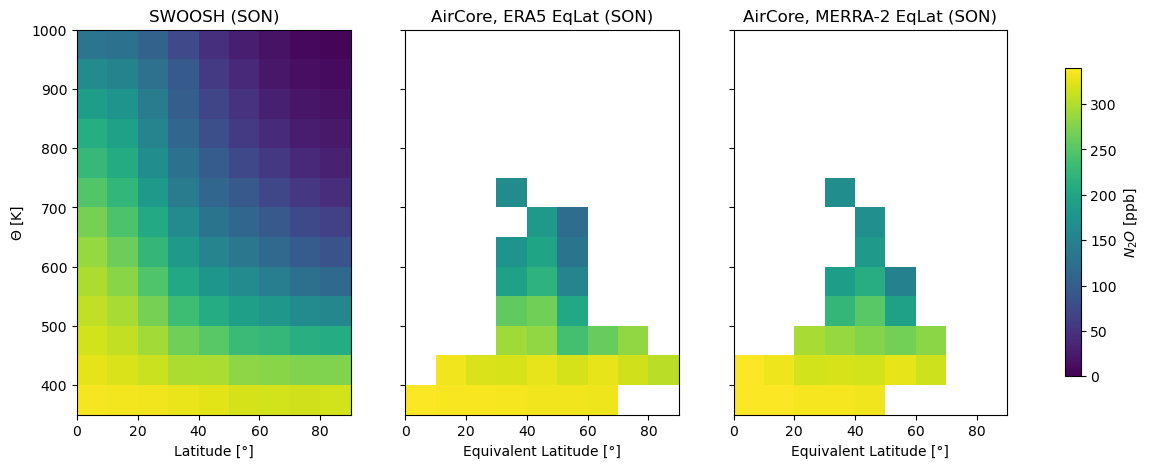

In [408]:
fig, axes = plot_swoosh_aircore_comparison('SON', vertical='theta')

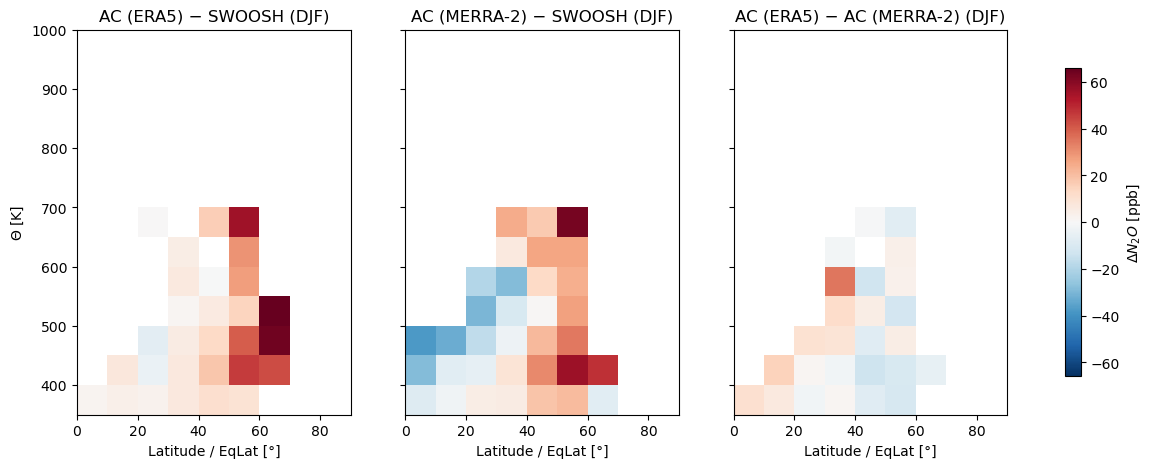

In [424]:
fig, axes, (diff_era5_swoosh, diff_merra2_swoosh, diff_era5_merra2) = plot_swoosh_aircore_diff('DJF', vertical='theta')

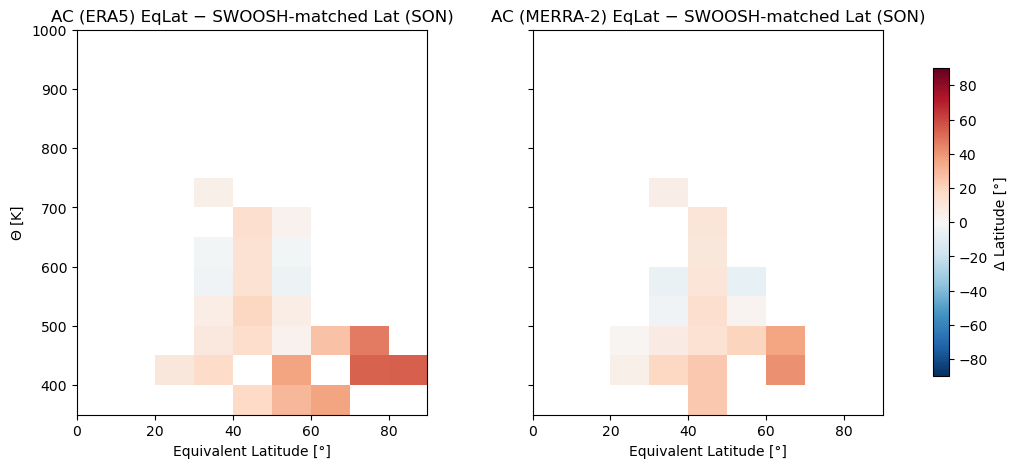

In [429]:
fig, axes, (era5_delta_lat, merra2_delta_lat) = plot_swoosh_aircore_delta_lat('SON')

In [411]:
def plot_aircore_std_count(season, vertical='theta'):
    """Plot per-bin std and count for AirCore N2O (ERA5 vs MERRA2 EqLat), NH only, one season.

    Two rows (std, count) x two columns (ERA5, MERRA2), same style as
    plot_swoosh_aircore_comparison. vertical: 'theta' or 'pressure'.
    """
    from matplotlib.colors import LogNorm

    if vertical == 'theta':
        era5_data = n2o_era5_eqlat_theta_seasonal
        merra2_data = n2o_merra2_eqlat_theta_seasonal
        vert_dim = 'theta'
        ylabel = '$\\Theta$ [K]'
    elif vertical == 'pressure':
        era5_data = n2o_era5_eqlat_pressure_seasonal
        merra2_data = n2o_merra2_eqlat_pressure_seasonal
        vert_dim = 'pressure'
        ylabel = 'Pressure [hPa]'
    else:
        raise ValueError(f"vertical must be 'theta' or 'pressure', got {vertical!r}")

    era5_nh = era5_data.sel(season=season, eqlat=slice(0, 90))
    merra2_nh = merra2_data.sel(season=season, eqlat=slice(0, 90))

    era5_relstd = 100 * era5_nh['std'] / era5_nh['mean']
    merra2_relstd = 100 * merra2_nh['std'] / merra2_nh['mean']

    era5_count = era5_nh['count'].where(era5_nh['count'] > 3)
    merra2_count = merra2_nh['count'].where(merra2_nh['count'] > 3)

    relstd_cmap = 'RdYlGn_r'
    relstd_vmax = 100

    count_vmax = max(era5_count.max().item(), merra2_count.max().item())
    count_vmin = min(era5_count.min().item(), merra2_count.min().item())
    count_norm = LogNorm(vmin=count_vmin, vmax=count_vmax)

    #std_vmax = max(era5_nh['std'].max().item(), merra2_nh['std'].max().item())
    #count_vmax = 200#max(era5_nh['count'].max().item(), merra2_nh['count'].max().item())

    fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharey=True)

    era5_relstd.plot(ax=axes[0, 0], x='eqlat', y=vert_dim, cmap=relstd_cmap, vmin=0, vmax=relstd_vmax, add_colorbar=False)
    axes[0, 0].set_title(f'AirCore rel. std, ERA5 EqLat ({season})')
    axes[0, 0].set_xlabel('')
    axes[0, 0].set_ylabel(ylabel)

    im_relstd = merra2_relstd.plot(ax=axes[0, 1], x='eqlat', y=vert_dim, cmap=relstd_cmap, vmin=0, vmax=relstd_vmax, add_colorbar=False)
    axes[0, 1].set_title(f'AirCore rel. std, MERRA-2 EqLat ({season})')
    axes[0, 1].set_xlabel('')
    axes[0, 1].set_ylabel('')

    era5_count.plot(ax=axes[1, 0], x='eqlat', y=vert_dim, norm=count_norm, add_colorbar=False)
    axes[1, 0].set_title(f'AirCore count, ERA5 EqLat ({season})')
    axes[1, 0].set_xlabel('Equivalent Latitude [°]')
    axes[1, 0].set_ylabel(ylabel)

    im_count = merra2_count.plot(ax=axes[1, 1], x='eqlat', y=vert_dim, norm=count_norm, add_colorbar=False)
    axes[1, 1].set_title(f'AirCore count, MERRA-2 EqLat ({season})')
    axes[1, 1].set_xlabel('Equivalent Latitude [°]')
    axes[1, 1].set_ylabel('')

    if vertical == 'theta':
        for ax in axes.flat:
            ax.set_ylim(350, 1000)
    else:
        # pressure decreases with height, so flip the (shared) y-axis to read bottom-to-top
        axes[0, 0].set_yscale('log')
        axes[0, 0].invert_yaxis()
        for ax in axes.flat:
            ax.set_ylim(400, 5)

    fig.colorbar(im_relstd, ax=axes[0, :], label='relative std($N_2O$) [%]', shrink=0.8, extend='max')
    fig.colorbar(im_count, ax=axes[1, :], label='count', shrink=0.8)
    return fig, axes


# fig, axes = plot_aircore_std_count('DJF', vertical='theta')

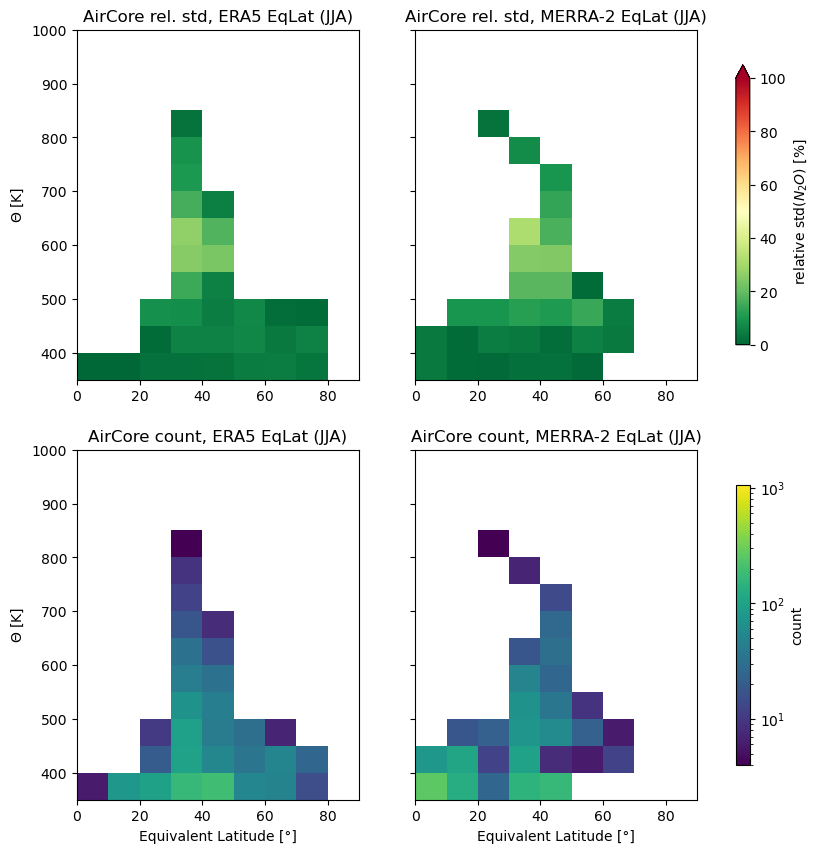

In [412]:
fig, axes = plot_aircore_std_count('JJA', vertical='theta')